# Deterministic Acceptance-Rejection Sampling in QMCPy

This notebook demonstrates the `AcceptanceRejection` and `AcceptanceRejectionReal` true measures, which implement Algorithms 2 and 3 from Zhu & Dick (2014). Replacing the standard random driver with a low-discrepancy sequence improves the convergence rate of the accepted samples from $O(N^{-1/2})$ to $O(N^{-1/s})$, where $s = d + 1$ is the driver dimension.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/acceptance_rejection.ipynb)

**Reference:** Zhu, H. & Dick, J. (2014). *Discrepancy bounds for deterministic acceptance-rejection samplers.* Electronic Journal of Statistics, 8(1), 678–707. [DOI: 10.1214/14-EJS898](https://doi.org/10.1214/14-EJS898)

## Setup

In [1]:
from qmcpy import *
from qmcpy.true_measure import AcceptanceRejection, AcceptanceRejectionReal
import numpy as np
from scipy.stats import norm

In [2]:
from matplotlib import pyplot
%matplotlib inline
size = 14
pyplot.rc('font', size=size)
pyplot.rc('axes', titlesize=size)
pyplot.rc('axes', labelsize=size)
pyplot.rc('xtick', labelsize=size)
pyplot.rc('ytick', labelsize=size)
pyplot.rc('legend', fontsize=size)
pyplot.rc('figure', titlesize=size)

## Background

Standard acceptance-rejection (A-R) sampling draws a candidate point $x$ from a proposal distribution and a uniform threshold $u \sim \mathcal{U}[0,1]$. The candidate is accepted if

$$\psi(x) \geq L \cdot u$$

where $\psi$ is the (unnormalised) target density and $L = \sup_x \psi(x)$ is a known upper bound. The fraction of candidates accepted is $\alpha = C/L$, where $C = \int \psi(x)\,dx$.

The key insight of Zhu & Dick (2014) is to draw the candidate $x$ and threshold $u$ **together** as a single point from a $(t,m,s)$-net in dimension $s = d+1$, rather than independently at random. Because the net covers $[0,1]^s$ more uniformly than IID draws, the accepted samples inherit a lower star discrepancy. Theorem 1 of the paper gives the bound

$$D^*_N(\psi) \leq \frac{8}{C/L} \cdot s \cdot b^{t/s} \cdot (2p - q) \cdot N^{-1/s}$$

compared to $O(N^{-1/2})$ for standard random A-R. The driver must consist of exactly $M = b^m$ points (here $b=2$) to preserve the $(t,m,s)$-net property.

## Algorithm 2 — DAR on $[0,1]^d$

For a density $\psi : [0,1]^d \to \mathbb{R}_+$, the driver is a $(t,m,s)$-net in $s = d+1$ dimensions. Each driver point

$$q = (x_1, \ldots, x_d,\; u) \in [0,1]^{d+1}$$

contributes the candidate $x = (x_1,\ldots,x_d) \in [0,1]^d$ and the threshold $u \in [0,1]$. The candidate is accepted if

$$\psi(x) \geq L \cdot u$$

**Parameters supplied by the user:**
- $L$ — upper bound satisfying $\psi(x) \leq L$ for all $x \in [0,1]^d$
- $C$ — integral of $\psi$ over $[0,1]^d$ (determines the acceptance rate $C/L$)

**Example:** target density $\psi(x) = 2x$ on $[0,1]$, so $L=2$, $C=1$, acceptance rate $= 0.5$. The normalised density is $f(x) = 2x$, which has mean $\mathbb{E}[X] = 2/3$.

In [3]:
def psi(x):
    # x shape: (N, d)
    return 2 * x[:, 0]

# driver dimension must be d+1 = 2
sampler = DigitalNetB2(dimension=2, seed=7)
measure = AcceptanceRejection(
    sampler,
    target_density   = psi,
    upper_bound      = 2.,   # L = sup psi
    density_integral = 1.,   # C = integral of psi over [0,1]
)
print(measure)

AcceptanceRejection (AbstractTrueMeasure)
    target_dim      1
    upper_bound     2^(1)
    density_integral 1
    acceptance_rate 2^(-1)


In [4]:
samples = measure.gen_samples(n=1024)

# true mean: E[X] = integral_0^1 x * 2x dx = 2/3
true_mean = 2/3

print('Shape:           ', samples.shape)
print('Sample mean E[X]:', samples.mean().round(4))
print('True mean E[X]:  ', round(true_mean, 4))

Shape:            (1024, 1)
Sample mean E[X]: 0.6683
True mean E[X]:   0.6667


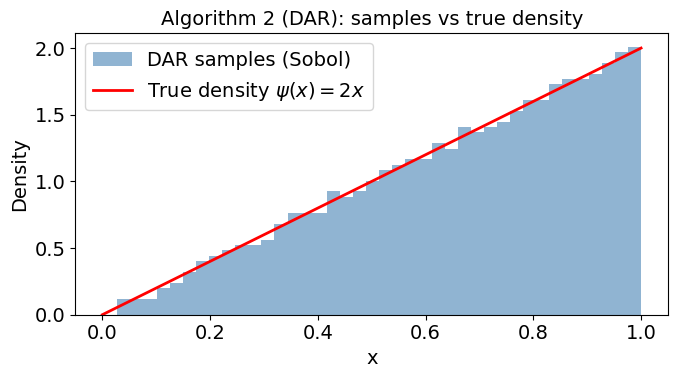

In [5]:
x_grid = np.linspace(0, 1, 200)

fig, ax = pyplot.subplots(figsize=(7, 4))
ax.hist(samples[:, 0], bins=40, density=True,
        alpha=0.6, color='steelblue', label='DAR samples (Sobol)')
ax.plot(x_grid, 2 * x_grid, 'r-', lw=2, label=r'True density $\psi(x)=2x$')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Algorithm 2 (DAR): samples vs true density')
ax.legend()
pyplot.tight_layout()
pyplot.show()

## Continued Sampling

In many applications — such as adaptive algorithms or stopping-criterion routines — samples are generated in **batches** rather than all at once. For this to preserve the low-discrepancy property of the QMC driver, each new batch must **continue the same driver sequence** rather than restarting it from the beginning.

`AcceptanceRejection` supports this via the `n_min` / `n_max` interface:

- `gen_samples(n_min=0, n_max=N)` — resets the driver and returns the first `N` accepted samples.
- `gen_samples(n_min=N, n_max=2*N)` — continues the driver from where it left off and returns the next `N` accepted samples.

**Why does the driver offset matter?**

The accepted samples inherit their low-discrepancy from the underlying $(t,m,s)$-net. If you restart the driver for every batch, each batch independently looks uniform — but the **combined** set of samples does not have the net structure that gives the $O(N^{-1/s})$ discrepancy bound. By tracking the driver offset across calls, the full sequence of accepted samples retains the theoretical guarantee.

**User responsibility:** if you switch to a different target density or sampler, call `gen_samples(n_min=0, ...)` to reset. The code cannot detect this automatically — continuing the old driver offset with a new density would give valid accepted samples but without the discrepancy guarantee.

In [6]:
# --- Continued sampling demo ---

# Fresh measure for a clean demo
sampler_cont = DigitalNetB2(dimension=2, seed=7)
measure_cont = AcceptanceRejection(
    sampler_cont, psi, upper_bound=2., density_integral=1.
)

# Call 1: first 8 samples
batch1 = measure_cont.gen_samples(n_min=0, n_max=8)
print("Batch 1 (n_min=0, n_max=8):")
print(batch1.T)

# Call 2: next 8 samples — driver resumes from where it left off
batch2 = measure_cont.gen_samples(n_min=8, n_max=16)
print("\nBatch 2 (n_min=8, n_max=16):")
print(batch2.T)

# Verify: two batches combined equal one single call of 16
measure_single = AcceptanceRejection(
    DigitalNetB2(dimension=2, seed=7), psi, upper_bound=2., density_integral=1.
)
all_at_once = measure_single.gen_samples(n_min=0, n_max=16)
print("\nAll at once (n_min=0, n_max=16):")
print(all_at_once.T)

combined = np.concatenate([batch1, batch2], axis=0)
print("\nTwo batches match single call:", np.allclose(combined, all_at_once))

# --- Error case: calling with n_min > 0 without a prior reset ---
print("\n--- Error case ---")
measure_err = AcceptanceRejection(
    DigitalNetB2(dimension=2, seed=7), psi, upper_bound=2., density_integral=1.
)
try:
    measure_err.gen_samples(n_min=8, n_max=16)
except Exception as e:
    print(f"Caught expected error: {e}")

Batch 1 (n_min=0, n_max=8):
[[0.98676255 0.56816656 0.83330484 0.26646599 0.64218506 0.87606951
  0.44193255 0.78724815]]

Batch 2 (n_min=8, n_max=16):
[[0.70526146 0.94012701 0.38196202 0.84916918 0.92367977 0.50624678
  0.74653437 0.98139635]]

All at once (n_min=0, n_max=16):
[[0.98676255 0.56816656 0.83330484 0.26646599 0.64218506 0.87606951
  0.44193255 0.78724815 0.70526146 0.94012701 0.38196202 0.84916918
  0.92367977 0.50624678 0.74653437 0.98139635]]

Two batches match single call: True

--- Error case ---
Caught expected error: n_min > 0 but no prior call was made. Call gen_samples with n_min=0 first.


## Algorithm 3 — DAR on $\mathbb{R}^d$

Algorithm 3 extends Algorithm 2 to densities on $\mathbb{R}^d$ by applying the inverse Rosenblatt transform (Lemma 4) to the first $d$ driver coordinates before the acceptance test.

Given a driver point $(u_1, \ldots, u_d, u_{d+1}) \in [0,1]^{d+1}$, define

$$z_j = F_j^{-1}(u_j), \quad j = 1, \ldots, d$$

where $F_j^{-1}$ is the marginal quantile function of an auxiliary distribution $H$ on $\mathbb{R}^d$. The candidate $z \in \mathbb{R}^d$ is accepted if

$$\psi(z) \geq L \cdot H(z) \cdot u_{d+1}$$

where $L$ satisfies $\psi(z) \leq L \cdot H(z)$ for all $z \in \mathbb{R}^d$.

**Parameters supplied by the user:**
- `inv_cdfs` — list of $d$ marginal quantile functions $[F_1^{-1}, \ldots, F_d^{-1}]$
- `H_func` — the auxiliary bound function $H(z)$
- $L$ — bound satisfying $\psi(z) \leq L \cdot H(z)$
- $C$ — integral of $\psi$ over $\mathbb{R}^d$

**Note:** `inv_cdfs` applies each quantile function independently per dimension, which is exact when $H$ is a product of independent marginals.

**Example:** target $\psi(z) = \phi(z;\,0,1)$ (standard Gaussian density), proposal $H(z) = \phi(z;\,0,4)$. Then $L = \sup_z \psi(z)/H(z) = 2$ (at $z=0$).

In [7]:
def psi_real(z):
    # z shape: (N, d)
    return norm.pdf(z[:, 0], loc=0, scale=1)

def H(z):
    return norm.pdf(z[:, 0], loc=0, scale=2)

sampler_real = DigitalNetB2(dimension=2, seed=7)
measure_real = AcceptanceRejectionReal(
    sampler_real,
    target_density   = psi_real,
    inv_cdfs         = [lambda u: norm.ppf(u, loc=0, scale=2)],
    H_func           = H,
    upper_bound      = 2.,   # L = sup psi/H
    density_integral = 1.,   # C = integral of psi over R
)
print(measure_real)

AcceptanceRejectionReal (AbstractTrueMeasure)
    target_dim      1
    upper_bound     2^(1)
    density_integral 1
    acceptance_rate 2^(-1)


In [8]:
samples_real = measure_real.gen_samples(n=1024)

# N(0,1): true mean = 0, true std = 1 by definition
true_mean_real = 0.
true_std_real  = 1.

print('Shape:            ', samples_real.shape)
print('Sample mean E[Z]:', samples_real.mean().round(4), ' (true:', true_mean_real, ')')
print('Sample std  SD:  ', samples_real.std().round(4),  ' (true:', true_std_real,  ')')

Shape:             (1024, 1)
Sample mean E[Z]: 0.0187  (true: 0.0 )
Sample std  SD:   0.9931  (true: 1.0 )


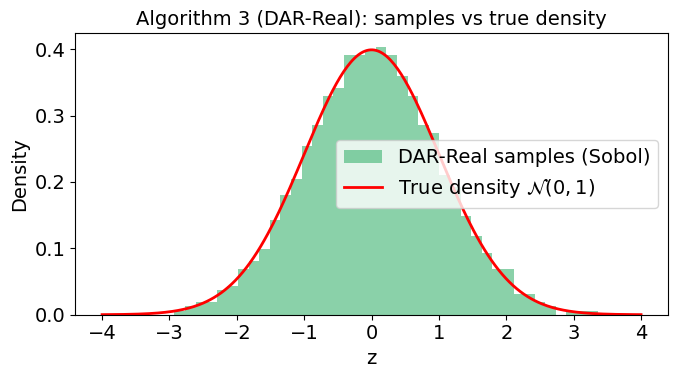

In [9]:
z_grid = np.linspace(-4, 4, 300)

fig, ax = pyplot.subplots(figsize=(7, 4))
ax.hist(samples_real[:, 0], bins=40, density=True,
        alpha=0.6, color='mediumseagreen', label='DAR-Real samples (Sobol)')
ax.plot(z_grid, norm.pdf(z_grid, 0, 1), 'r-', lw=2,
        label=r'True density $\mathcal{N}(0,1)$')
ax.set_xlabel('z')
ax.set_ylabel('Density')
ax.set_title('Algorithm 3 (DAR-Real): samples vs true density')
ax.legend()
pyplot.tight_layout()
pyplot.show()

## QMC vs Monte Carlo: Convergence of Star Discrepancy

The star discrepancy measures how closely the empirical distribution of the accepted samples matches the target $\psi$. For a 1-D target it is

$$D^*_N(\psi) = \sup_{t \in [0,1]} \left| \frac{\#\{i : x_i \leq t\}}{N} - \frac{1}{C}\int_0^t \psi(x)\,dx \right|$$

Theorem 1 of Zhu & Dick (2014) predicts:
- **Sobol driver (DAR):** $D^*_N = O(N^{-1/s})$ with $s=2$ for $d=1$, i.e. $O(N^{-1/2})$ in the worst case — but empirically faster due to the $\log N$ factors.
- **Random driver (standard A-R):** $D^*_N = O(N^{-1/2})$ always.

The plot below measures this empirically for $\psi(x) = 2x$ on $[0,1]$, where the CDF is $F(t) = t^2$ and $C = 1$.

In [10]:
def star_discrepancy(samples_1d, cdf, C, n_grid=500):
    """Empirical star discrepancy D*_N(psi) for 1-D samples."""
    N = len(samples_1d)
    s = np.sort(samples_1d)
    t = np.linspace(0, 1, n_grid + 1)
    empirical   = np.searchsorted(s, t, side='right') / N
    theoretical = cdf(t) / C
    return np.max(np.abs(empirical - theoretical))

# psi(x)=2x  =>  CDF: F(t) = t^2,  C = 1
cdf_linear = lambda t: t ** 2
C_linear   = 1.0

N_values = [2**k for k in range(5, 13)]   # 32 to 4096
n_reps   = 10

disc_sobol  = []
disc_random = []

for N in N_values:
    ds, dr = [], []
    for _ in range(n_reps):
        # Sobol driver
        m_sobol = AcceptanceRejection(
            DigitalNetB2(dimension=2, seed=None), psi,
            upper_bound=2., density_integral=1.)
        s_qmc = m_sobol.gen_samples(N, warn=False)
        ds.append(star_discrepancy(s_qmc[:, 0], cdf_linear, C_linear))
        # Random (IID) driver
        m_rand = AcceptanceRejection(
            IIDStdUniform(dimension=2, seed=None), psi,
            upper_bound=2., density_integral=1.)
        s_mc = m_rand.gen_samples(N, warn=False)
        dr.append(star_discrepancy(s_mc[:, 0], cdf_linear, C_linear))
    disc_sobol.append(np.median(ds))
    disc_random.append(np.median(dr))

disc_sobol  = np.array(disc_sobol)
disc_random = np.array(disc_random)

rate_sobol  = np.polyfit(np.log(N_values), np.log(disc_sobol),  1)[0]
rate_random = np.polyfit(np.log(N_values), np.log(disc_random), 1)[0]

print(f'Sobol  convergence rate: N^{{{rate_sobol:.3f}}}  (theory: better than N^{{-0.5}})')
print(f'Random convergence rate: N^{{{rate_random:.3f}}}  (theory: N^{{-0.5}})')

Sobol  convergence rate: N^{-0.878}  (theory: better than N^{-0.5})
Random convergence rate: N^{-0.535}  (theory: N^{-0.5})


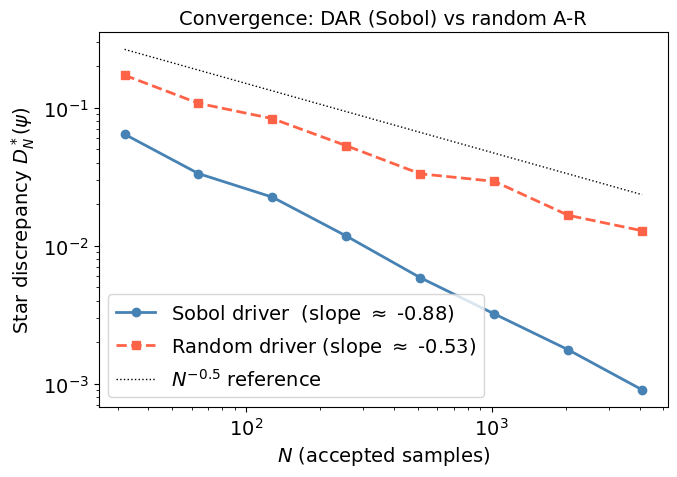

In [11]:
N_arr = np.array(N_values, float)

fig, ax = pyplot.subplots(figsize=(7, 5))
ax.loglog(N_arr, disc_sobol,  'o-', color='steelblue', lw=2, ms=6,
          label=f'Sobol driver  (slope $\\approx$ {rate_sobol:.2f})')
ax.loglog(N_arr, disc_random, 's--', color='tomato',    lw=2, ms=6,
          label=f'Random driver (slope $\\approx$ {rate_random:.2f})')
ax.loglog(N_arr, 1.5 * N_arr**(-0.5), 'k:', lw=1, label=r'$N^{-0.5}$ reference')
ax.set_xlabel('$N$ (accepted samples)')
ax.set_ylabel(r'Star discrepancy $D^*_N(\psi)$')
ax.set_title(r'Convergence: DAR (Sobol) vs random A-R')
ax.legend()
pyplot.tight_layout()
pyplot.show()